In [26]:
#Run first!
import pandas as pd
import glob
import os
import numpy as np
import scipy as sp
import matplotlib.pyplot as plt
import math
from tqdm import tqdm
import itertools
import seaborn as sns
import statsmodels
import pingouin as pg


1. Process data from each EEG summary file

plan:
- Make script to read each CSV file, parse it by row and column, and create a series of values. They will be blocks 2-1, 3-1, ... 6-1.
- Duplicate the script to also process and store data for all 3 effect groups
- Make a plot that plots each block in order for all participants, and plots a linear trendline for each treatment group
- Edit SMLfigures to create a CSV file that stores average compensation for each participant compared to baseline and saves it all by participant number
- Make a plot that has adaptation magnitude on one axis and change in EEG amplitude on another

In [ ]:
# TROUBLESHOOTING - IGNORE
adapters_file = 'MeanP2adapters.csv'
datatable = pd.read_csv(adapters_file, sep=r'\s*,\s*', header=0, encoding='ascii', engine='python')

block_1 = datatable["bin1_Midline"]

block1 = block_1.to_numpy()
block2 = datatable["bin2_Midline"].to_numpy

#len() == len(arr2)
#print(datatable.columns.tolist())
#datatable.head()
print(block1.shape)
#print(block2.shape)
print(type(block1))


(9,)
<class 'numpy.ndarray'>


Run code to extract dataframes from each CSV, add a column identifying the group, and concatenate before running ANOVA

In [27]:
## Input relevant values

# CSV file names
adapters_file = 'MeanP2adaptersno9.csv'
nonadapters_file = 'MeanP2nonadapters.csv'
controls_file = 'MeanP2controls.csv'
# Group names
name_controls = "control"
name_nonadapters = "nonadapter"
name_adapters = "adapter"

## Function to create dataframes for each CSV file and add group name 
def uploadvals(csvfile, groupname):

    data = pd.read_csv(csvfile, sep=r'\s*,\s*', header=0, encoding='ascii', engine='python')
    datatable = data.dropna(subset=["bin1_Midline"])

    datatable['group'] = groupname

    return datatable

## Combine dataframes into one big dataframe
df_adapters = uploadvals(adapters_file,name_adapters)
df_nonadapters = uploadvals(nonadapters_file,name_nonadapters)
df_controls = uploadvals(controls_file,name_controls)

df_list = [df_adapters, df_nonadapters, df_controls]
df = pd.concat(df_list)
df['group'] = df['group'].astype('object') #change group name to object for ANOVA to work
df['ERPset'] = df['ERPset'].astype('object')
df.info()


<class 'pandas.DataFrame'>
Index: 26 entries, 0 to 9
Data columns (total 10 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   bin1_Midline  26 non-null     float64
 1   bin2_Midline  26 non-null     float64
 2   bin3_Midline  26 non-null     float64
 3   bin4_Midline  26 non-null     float64
 4   bin5_Midline  26 non-null     float64
 5   bin6_Midline  26 non-null     float64
 6   bin7_Midline  26 non-null     float64
 7   bin8_Midline  26 non-null     float64
 8   ERPset        26 non-null     object 
 9   group         26 non-null     object 
dtypes: float64(8), object(2)
memory usage: 2.2+ KB


full boxplot (raw)

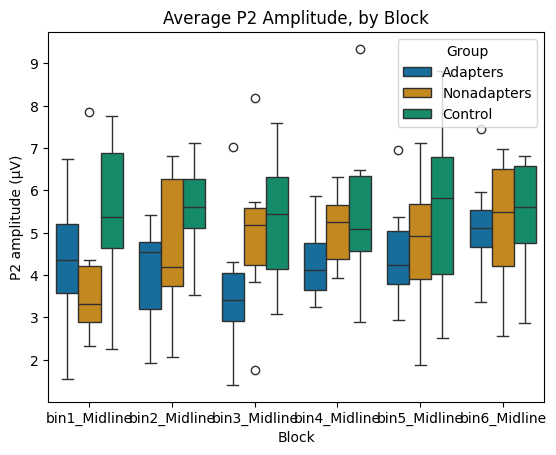

,group,ERPset,block,value
0,adapter,1_SML_diff,bin1_Midline,1.542
1,adapter,11_SML_diff,bin1_Midline,3.645
2,adapter,15_SML_diff,bin1_Midline,4.708
3,adapter,22_SML_diff,bin1_Midline,3.996
4,adapter,23_SML_diff,bin1_Midline,5.365
...,...,...,...,...
151,control,16_SML_diff,bin6_Midline,2.878
152,control,19_SML_diff,bin6_Midline,6.726
153,control,20_SML_diff,bin6_Midline,6.619
154,control,29_SML_diff,bin6_Midline,4.935


In [ ]:

#blocks = df[['bin1_Midline', 'bin2_Midline', 'bin3_Midline', 'bin4_Midline', 'bin5_Midline', 'bin6_Midline']]
df_long = df.melt(
    id_vars=["group", "ERPset"],           # stays as grouping variable
    value_vars=['bin1_Midline', 'bin2_Midline', 'bin3_Midline', 'bin4_Midline', 'bin5_Midline', 'bin6_Midline'],
    var_name="block",       # column name indicator
    value_name="value",      # actual values
    )       
# Plot
sns.boxplot(data = df_long, x = 'block', y = 'value', hue='group', palette='colorblind')
plt.title('Average P2 Amplitude, by Block')
plt.xlabel('Block')
plt.ylabel('P2 amplitude (µV)')

# Customize the legend
handles, labels = plt.gca().get_legend_handles_labels()
plt.legend(handles=handles, labels=['Adapters', 'Nonadapters', 'Control'], title='Group')
plt.show()

df_long

Check assumptions, then ANOVA:
1) Equal variance - levene's test
2) Normal distribution of each group
3) Run ANOVA (two way ANOVA with repeated measures)
4) Run post-hoc test (Bonferroni)

In [ ]:
# Levene Test

all_adapters = df_long[df_long['group'] == 'adapter']
all_nonadapters = df_long[df_long['group'] == 'nonadapter']
all_control = df_long[df_long['group'] == 'control']

lev_adapters = all_adapters['value'].to_numpy()
lev_nonadapters = all_nonadapters['value'].to_numpy()
lev_control = all_control['value'].to_numpy()

stat, p = sp.stats.levene(lev_adapters, lev_nonadapters, lev_control)

print(stat)
# Levene test result: p=0.06859 stat=2.725. Yikes!
# Rerun without P9: p=0.3605 stat=1.027. Better

1.0270090852678877


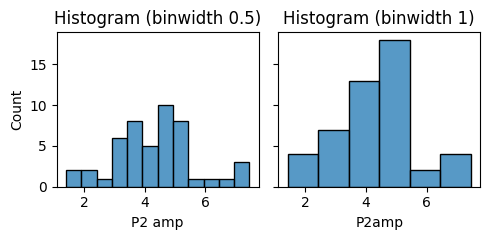

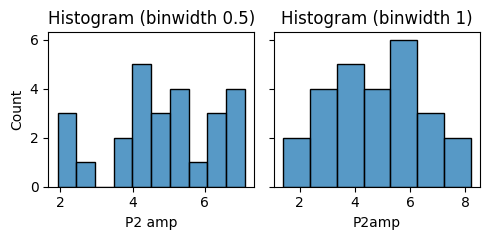

In [ ]:

# Check if normally distributed (groups)
# Set up 2 subplots
fig, axes = plt.subplots(1, 2, figsize=(5, 2.5), sharey=True)

# Plot amp per group with bin width of 0.5
sns.histplot(data=lev_adapters, binwidth=0.5, ax=axes[0])
axes[0].set_title('Histogram (binwidth 0.5)')
axes[0].set_xlabel('P2 amp')
axes[0].set_ylabel('Count')

# Plot amp per group with bin width of 1
sns.histplot(data=lev_adapters, binwidth=1, ax=axes[1])
axes[1].set_title('Histogram (binwidth 1)')
axes[1].set_xlabel('P2amp')

# Adjust layout
plt.tight_layout()
plt.show()

#IDK if this is normally distributed, tbh. Close enough?

# Check if normally distributed (groups)
# Set up 2 subplots
fig, axes = plt.subplots(1, 2, figsize=(5, 2.5), sharey=True)

# Plot amp with bin width of 0.5
sns.histplot(data=df, x="bin2_Midline", binwidth=0.5, ax=axes[0])
axes[0].set_title('Histogram (binwidth 0.5)')
axes[0].set_xlabel('P2 amp')
axes[0].set_ylabel('Count')

# Plot amp with bin width of 1
sns.histplot(data=df, x="bin3_Midline", binwidth=1, ax=axes[1])
axes[1].set_title('Histogram (binwidth 1)')
axes[1].set_xlabel('P2amp')

# Adjust layout
plt.tight_layout()
plt.show()

#Maybe P09 needs to be rejected after all


In [37]:
# Run ANOVA (group x block)

aov = pg.mixed_anova(data=df_long, dv='value', within='block', between='group', subject='ERPset')
pg.print_table(aov)


ANOVA SUMMARY

Source           SS    DF1    DF2      MS      F    p_unc    np2      eps
-----------  ------  -----  -----  ------  -----  -------  -----  -------
group        35.780      2     23  17.890  2.157    0.139  0.158  nan
block         7.650      5    115   1.530  1.331    0.256  0.055    0.780
Interaction  13.398     10    115   1.340  1.166    0.321  0.092  nan



Run a script to extract values from CSV and subtract all values from Block 1

In [32]:
adapters_file = 'MeanP2adapters.csv'
nonadapters_file = 'MeanP2nonadapters.csv'
controls_file = 'MeanP2controls.csv'

def meanamp(csvfile):

    data = pd.read_csv(csvfile, sep=r'\s*,\s*', header=0, encoding='ascii', engine='python')
    datatable = data.dropna(subset=["bin1_Midline"])

    block1 = datatable["bin1_Midline"].to_numpy()
    block2 = datatable["bin2_Midline"].to_numpy()
    block3 = datatable["bin3_Midline"].to_numpy()
    block4 = datatable["bin4_Midline"].to_numpy()
    block5 = datatable["bin5_Midline"].to_numpy()
    block6 = datatable["bin6_Midline"].to_numpy()

    one = block2 - block1
    two = block3 - block1
    three = block4 - block1
    four = block5 - block1
    five = block6 - block1

    return one, two, three, four, five

adapters = meanamp(adapters_file)
adapt1, adapt2, adapt3, adapt4, adapt5 = adapters

nonadapters = meanamp(nonadapters_file)
nonadapt1, nonadapt2, nonadapt3, nonadapt4, nonadapt5 = nonadapters

controls = meanamp(controls_file)
con1, con2, con3, con4, con5 = controls

print(adapt1)
print(adapt5.shape)


[ 0.461  2.662  0.835 -0.114  0.809 -3.446  0.252 -1.327 -0.375]
(9,)


In [36]:
adapters_file = 'MeanP2adapters.csv'
nonadapters_file = 'MeanP2nonadapters.csv'
controls_file = 'MeanP2controls.csv'

def meanamppercent(csvfile):

    data = pd.read_csv(csvfile, sep=r'\s*,\s*', header=0, encoding='ascii', engine='python')
    datatable = data.dropna(subset=["bin1_Midline"])

    block1 = datatable["bin1_Midline"].to_numpy()
    block2 = datatable["bin2_Midline"].to_numpy()
    block3 = datatable["bin3_Midline"].to_numpy()
    block4 = datatable["bin4_Midline"].to_numpy()
    block5 = datatable["bin5_Midline"].to_numpy()
    block6 = datatable["bin6_Midline"].to_numpy()

    one = ((block2 / block1) *100)-100
    two = ((block3 / block1) *100)-100
    three = ((block4 / block1) *100)-100
    four = ((block5 / block1) *100)-100
    five = ((block6 / block1) *100)-100

    return one, two, three, four, five

adaptersp = meanamppercent(adapters_file)
adapt1p, adapt2p, adapt3p, adapt4p, adapt5p = adaptersp

nonadaptersp = meanamppercent(nonadapters_file)
nonadapt1p, nonadapt2p, nonadapt3p, nonadapt4p, nonadapt5p = nonadaptersp

controlsp = meanamppercent(controls_file)
con1p, con2p, con3p, con4p, con5p = controlsp

print(adapt1p)


[ 29.89623865  24.24187232  22.90809328  -2.42141037  20.24524525
 -64.23112768   7.53588517 -19.65052569  -7.27590221]


2. For plotting adapters by block

<function matplotlib.pyplot.show(close=None, block=None)>

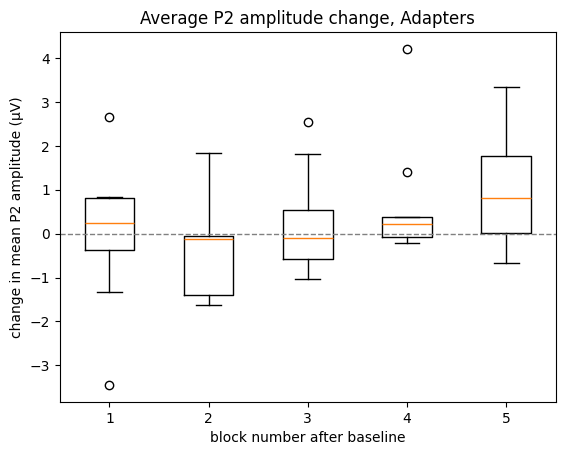

In [42]:
plotadapt = [adapt1, adapt2, adapt3, adapt4, adapt5]
plt.boxplot(plotadapt, positions = [1, 2, 3, 4, 5], tick_labels = ['1', '2', '3', '4', '5'])

plt.title('Average P2 amplitude change, Adapters')
plt.xlabel('block number after baseline')
plt.ylabel('change in mean P2 amplitude (µV)')
plt.axhline(0, color='gray', linestyle='--', linewidth=1)

plt.savefig('adapters_P2change', format='pdf', bbox_inches='tight')
plt.show

<function matplotlib.pyplot.show(close=None, block=None)>

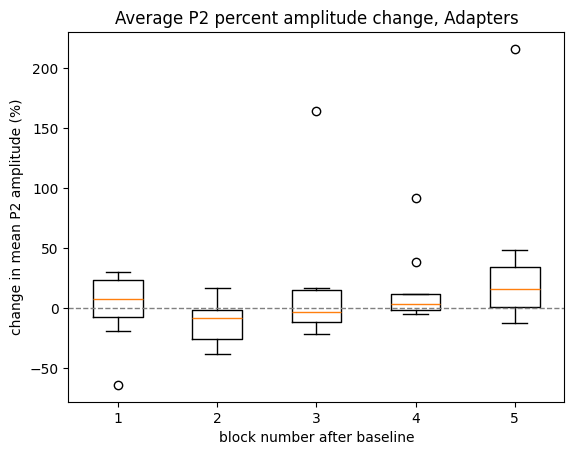

In [ ]:
plotadaptp = [adapt1p, adapt2p, adapt3p, adapt4p, adapt5p]
plt.boxplot(plotadaptp, positions = [1, 2, 3, 4, 5], tick_labels = ['1', '2', '3', '4', '5'])

plt.title('Average P2 percent amplitude change, Adapters')
plt.xlabel('block number after baseline') 
plt.ylabel('change in mean P2 amplitude (%)')
plt.axhline(0, color='gray', linestyle='--', linewidth=1)

plt.savefig('adapters_P2percentchange', format='pdf', bbox_inches='tight')
plt.show

<function matplotlib.pyplot.show(close=None, block=None)>

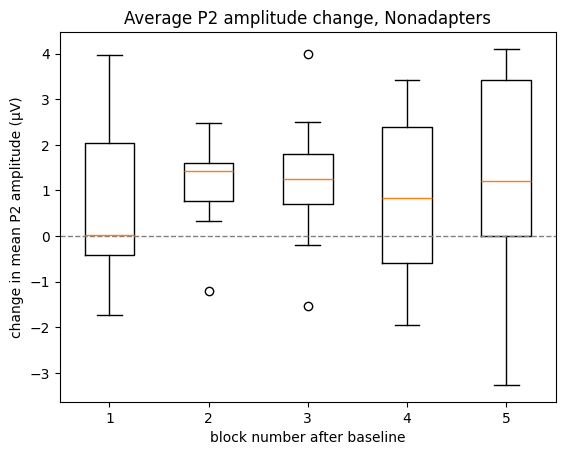

In [44]:
plotnonadapt = [nonadapt1, nonadapt2, nonadapt3, nonadapt4, nonadapt5]
plt.boxplot(plotnonadapt, positions = [1, 2, 3, 4, 5], tick_labels = ['1', '2', '3', '4', '5'])

plt.title('Average P2 amplitude change, Nonadapters')
plt.xlabel('block number after baseline')
plt.ylabel('change in mean P2 amplitude (µV)')
plt.axhline(0, color='gray', linestyle='--', linewidth=1)

plt.savefig('nonadapters_P2change', format='pdf', bbox_inches='tight')
plt.show

<function matplotlib.pyplot.show(close=None, block=None)>

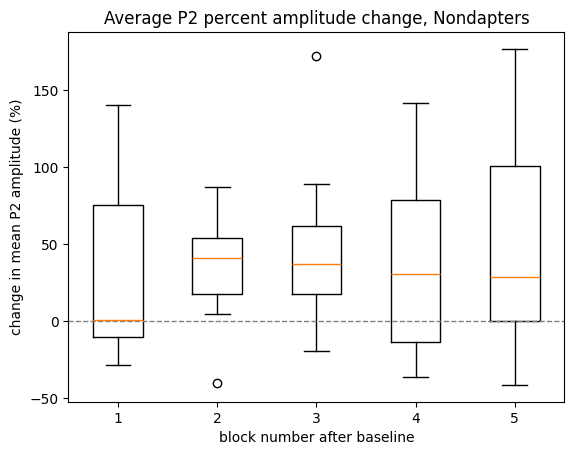

In [45]:
plotnonadaptp = [nonadapt1p, nonadapt2p, nonadapt3p, nonadapt4p, nonadapt5p]
plt.boxplot(plotnonadaptp, positions = [1, 2, 3, 4, 5], tick_labels = ['1', '2', '3', '4', '5'])

plt.title('Average P2 percent amplitude change, Nondapters')
plt.xlabel('block number after baseline')
plt.ylabel('change in mean P2 amplitude (%)')
plt.axhline(0, color='gray', linestyle='--', linewidth=1)

plt.savefig('nonadapters_P2percentchange', format='pdf', bbox_inches='tight')
plt.show

<function matplotlib.pyplot.show(close=None, block=None)>

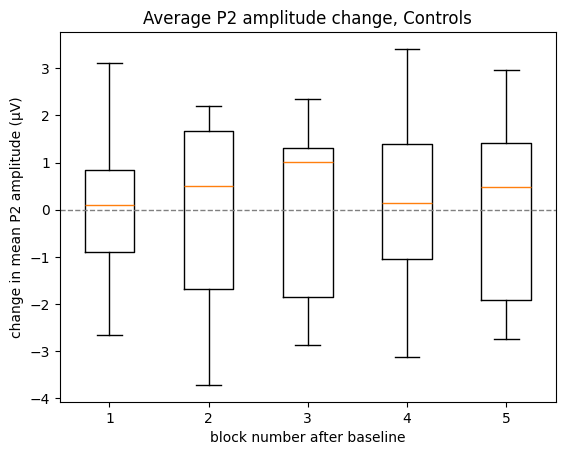

In [46]:
plotcontrol = [con1, con2, con3, con4, con5]
plt.boxplot(plotcontrol, positions = [1, 2, 3, 4, 5], tick_labels = ['1', '2', '3', '4', '5'])

plt.title('Average P2 amplitude change, Controls')
plt.xlabel('block number after baseline')
plt.ylabel('change in mean P2 amplitude (µV)')
plt.axhline(0, color='gray', linestyle='--', linewidth=1)

plt.savefig('controls_P2change', format='pdf', bbox_inches='tight')
plt.show

<function matplotlib.pyplot.show(close=None, block=None)>

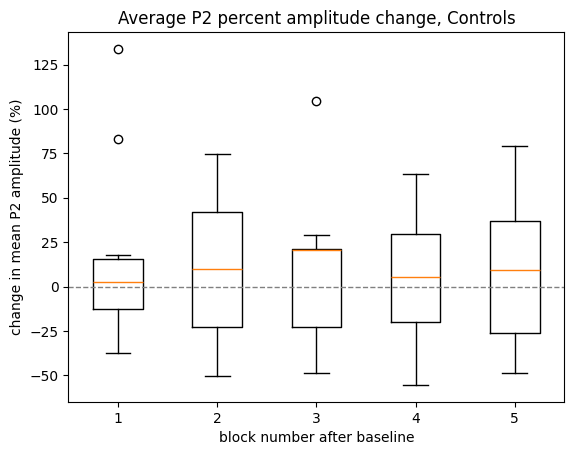

In [47]:
plotcontrolp = [con1p, con2p, con3p, con4p, con5p]
plt.boxplot(plotcontrolp, positions = [1, 2, 3, 4, 5], tick_labels = ['1', '2', '3', '4', '5'])

plt.title('Average P2 percent amplitude change, Controls')
plt.xlabel('block number after baseline')
plt.ylabel('change in mean P2 amplitude (%)')
plt.axhline(0, color='gray', linestyle='--', linewidth=1)

plt.savefig('controls_P2percentchange', format='pdf', bbox_inches='tight')
plt.show